In [1]:
import importlib.util
import sys
import subprocess

def check_installation_and_install(package_name):
    spec = importlib.util.find_spec(package_name)
    if spec is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
    else:
        print(package_name + " is installed");

check_installation_and_install("pandas")
check_installation_and_install("matplotlib")
check_installation_and_install("numpy")
check_installation_and_install("wfdb")

pandas is installed
matplotlib is installed
numpy is installed


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn import linear_model
from sklearn.tree import DecisionTreeClassifier 
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier


## Load Data

In [4]:
file_directory = "./Cleaned_Data"

df = pd.read_csv(os.path.join(file_directory,"Cleaned_Data.csv"))

df = df.drop(columns = ['Unnamed: 0'])

df.head()

,RXPACC,CIR745,MAX_NOISE,CIR740,CIR749,CIR_PWR,CIR750,CIR351,CIR333,CIR349,...,CIR702,CIR582,CIR86,CIR326,CIR526,CIR646,CIR94,CIR550,NLOS,RANGE
0,5.340950,-3.028304,7.167516,0.671436,0.557552,-0.099376,-0.972926,1.229448,0.622879,-0.593125,...,2.178883,-0.084384,-0.324265,-0.469083,0.514634,2.009885,-1.959175,1.643617,0.0,3.90
1,-2.534061,-0.029293,0.643117,-0.960087,1.775944,0.475413,0.948206,0.170687,0.134706,0.787721,...,0.667394,0.074283,0.515298,-0.593969,0.599629,0.347457,1.568480,0.251293,0.0,0.66
2,1.283108,-1.565217,3.643742,0.089303,1.830167,-1.457966,0.628919,2.070791,1.543473,-0.933256,...,-0.330063,0.627584,1.378630,-0.147590,-1.083272,0.677961,-0.514340,-0.666093,1.0,7.86
3,-1.945046,1.072899,3.781957,0.661626,1.057777,-1.902863,-2.566024,-1.515620,-0.998419,-1.399501,...,-0.932563,0.453547,-0.386218,-0.884229,-0.420500,-1.041305,0.064714,-0.807105,1.0,3.48
4,-1.134185,-2.722373,-0.262928,1.140229,-1.513667,-1.281015,-0.305696,-1.814682,0.200200,1.574470,...,0.270637,0.330699,-0.593827,-0.094747,-0.719300,-0.355553,0.570049,0.518913,0.0,1.19


## Split data 

In [5]:
original_df = df

X = original_df.drop(['NLOS'], axis=1)
y = original_df['NLOS']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# print(X_train.describe())


# Classification of NLOS and LOS data

## Decision Tree Classification

In [6]:
dtc = DecisionTreeClassifier(criterion="entropy", max_depth=5)
dtc = dtc.fit(X_train,y_train)

dtc_y_pred = dtc.predict(X_test)


rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc = rfc.fit(X_train,y_train)

rfc_y_pred = rfc.predict(X_test)

### Accuracy Testing

In [7]:
print("Decision Tree Classifier Accuracy:",metrics.accuracy_score(y_test, dtc_y_pred))

print("Random Forest Classifier Accuracy:",metrics.accuracy_score(y_test, rfc_y_pred))

Decision Tree Classifier Accuracy: 0.678204029147021
Random Forest Classifier Accuracy: 0.6836690955850836


## KNN

In [8]:
numNeighbors = [1, 2, 3, 4, 5, 6, 7,  10]
trainAcc = []
testAcc = []

for k in numNeighbors:
    clf1 = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)
    clf1.fit(X_train, y_train)
    Y_predTrain = clf1.predict(X_train)
    Y_predTest = clf1.predict(X_test)

    train_accuracy = accuracy_score(y_train, Y_predTrain)
    test_accuracy = accuracy_score(y_test, Y_predTest)

    trainAcc.append(accuracy_score(y_train, Y_predTrain))
    testAcc.append(accuracy_score(y_test, Y_predTest))

    print(f'k={k}, Training Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}')    

k=1, Training Accuracy: 1.0000, Test Accuracy: 0.5946
k=2, Training Accuracy: 0.7939, Test Accuracy: 0.6036
k=3, Training Accuracy: 0.8001, Test Accuracy: 0.6138
k=4, Training Accuracy: 0.7525, Test Accuracy: 0.6245
k=5, Training Accuracy: 0.7563, Test Accuracy: 0.6285
k=6, Training Accuracy: 0.7351, Test Accuracy: 0.6349
k=7, Training Accuracy: 0.7396, Test Accuracy: 0.6405
k=10, Training Accuracy: 0.7190, Test Accuracy: 0.6539


## Neural Network

Text(0, 0.5, 'Accuracy')

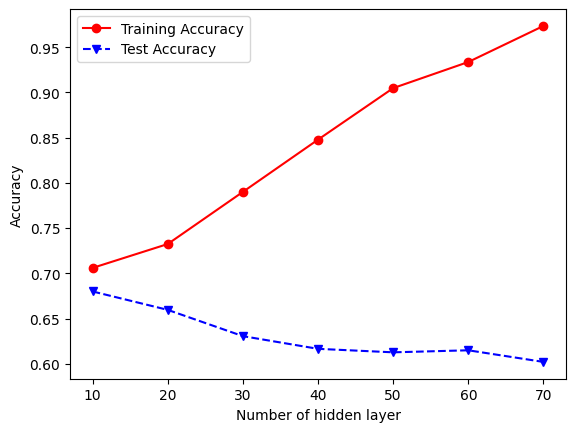

In [9]:
hidden_layer_sizes = [(10,10,10), (20,20,20), (30,30,30), (40,40,40), (50,50,50), (60,60,60), (70,70,70)]
trainAcc = []
testAcc = []

for k in hidden_layer_sizes:
    clf6 = MLPClassifier(solver='adam',hidden_layer_sizes=k, learning_rate='adaptive',random_state=1,max_iter=1000)
    clf6.fit(X_train, y_train)
    Y_predTrain = clf6.predict(X_train)
    Y_predTest = clf6.predict(X_test)
    trainAcc.append(accuracy_score(y_train, Y_predTrain))
    testAcc.append(accuracy_score(y_test, Y_predTest))
hidden_layer_size=[x[0] for x in hidden_layer_sizes]
plt.plot(hidden_layer_size, trainAcc, 'ro-', hidden_layer_size, testAcc,'bv--')
plt.legend(['Training Accuracy','Test Accuracy'])
plt.xlabel('Number of hidden layer')
plt.ylabel('Accuracy')

# Prediction of range

## Multilinear Regression

In [10]:
original_df_range = df

X = original_df_range.drop(['RANGE'], axis=1)
y = original_df_range['RANGE']

X_train_range, X_test_range, y_train_range, y_test_range = train_test_split(X, y, test_size=0.3, random_state=42)

regr = linear_model.LinearRegression()
regr.fit(X_train_range, y_train_range) 

y_pred_range = regr.predict(X_test_range)


### Accuracy Testing

In [11]:
# Evaluate the model
mse = mean_squared_error(y_test_range, y_pred_range)
r2 = r2_score(y_test_range, y_pred_range)

# Print the results
print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared: {r2:.4f}")

Mean Squared Error: 4.3378
R-squared: 0.2072
